# 🐒 Cuidado! Esse macaco morde

Vamos mostrar aqui como a máquina faria para dizer se um macaco morde ou não.

1. Primeiro vamos fazer o treino com os macacos de 01 a 20 já classificados.
2. O computador aprende as regras para formar a Árvore de Decisão.
3. Por último, testamos o computador com macacos que ele não viu antes, pra ver se ele aprendeu de verdade.

In [1]:
# Bibliotecas que vamos usar
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

## 1. As listas de macacos

A folha de atividade já nos diz quais macacos mordem (😬) e quais não mordem (😊),
tanto no grupo de **treino** quanto no grupo de **teste**.


In [7]:
# Pasta onde estão as 40 imagens dos macacos (macaco_01.png ... macaco_40.png)
PASTA_IMAGENS = "../data"

# --- Dados de TREINAMENTO (o computador vai aprender com esses) ---
treino_mordem     = [1, 2, 5, 9, 10, 14, 15, 16, 17, 28, 33, 35, 36]
treino_nao_mordem = [4, 7, 12, 19, 22, 23, 24, 25, 30, 32, 37, 38, 39, 40]

# --- Dados de TESTE (o computador NUNCA viu esses, é a prova real) ---
teste_mordem     = [6, 13, 18, 34]
teste_nao_mordem = [3, 8, 11, 20, 21, 26, 27, 29, 31]

print("Macacos de treino:", len(treino_mordem) + len(treino_nao_mordem))
print("Macacos de teste: ", len(teste_mordem) + len(teste_nao_mordem))

Macacos de treino: 27
Macacos de teste:  13


## 2. Transformando as carinhas em números

Um computador não "vê" uma imagem como a gente. Pra ele, uma imagem é só uma tabela de números
(cada pixel tem um valor). Então vamos:

1. Deixar a imagem em preto e branco (fica mais simples).
2. Diminuir o tamanho pra 20x20 pixels (só pra não ficar pesado).
3. "Esticar" essa grade de pixels numa lista de números.

Essa lista de números é o que chamamos de **features** (características) — é o que a Árvore de Decisão vai usar pra aprender.


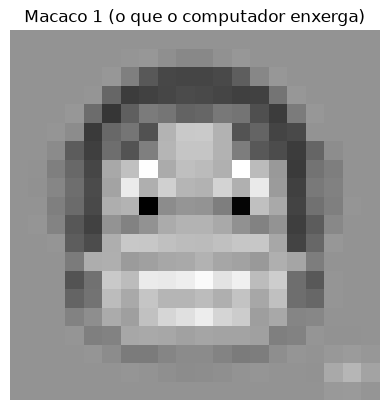

In [ ]:
TAMANHO = 20  # a imagem vira 20x20 pixels

def carregar_imagem(numero_macaco):
    """Abre a imagem do macaco e transforma numa lista de números (0 a 1)."""
    caminho = f"{PASTA_IMAGENS}/macaco_{numero_macaco:02d}.png"
    imagem = Image.open(caminho).convert("L").resize((TAMANHO, TAMANHO))  # "L" = escala de cinza
    return np.array(imagem).flatten() / 255.0

# Vamos espiar como fica o macaco número 1 em preto e branco, pequenininho
plt.imshow(np.array(Image.open(f"{PASTA_IMAGENS}/macaco_01.png").convert("L").resize((TAMANHO, TAMANHO))), cmap="gray")
plt.title("Macaco 1 (o que o computador enxerga)")
plt.axis("off")
plt.show()

## 3. Montando os conjuntos de treino e teste

Agora juntamos as imagens (já transformadas em números) com o rótulo certo:
- `1` = morde
- `0` = não morde


In [9]:
def montar_conjunto(lista_mordem, lista_nao_mordem):
    imagens = []
    rotulos = []
    numeros = []
    for numero in lista_mordem:
        imagens.append(carregar_imagem(numero))
        rotulos.append(1)  # morde
        numeros.append(numero)
    for numero in lista_nao_mordem:
        imagens.append(carregar_imagem(numero))
        rotulos.append(0)  # não morde
        numeros.append(numero)
    return np.array(imagens), np.array(rotulos), numeros

X_treino, y_treino, numeros_treino = montar_conjunto(treino_mordem, treino_nao_mordem)
X_teste,  y_teste,  numeros_teste  = montar_conjunto(teste_mordem, teste_nao_mordem)

print("Formato do treino:", X_treino.shape)
print("Formato do teste: ", X_teste.shape)


Formato do treino: (27, 400)
Formato do teste:  (13, 400)


## 4. Treinando a Árvore de Decisão 🌳

Uma árvore de decisão aprende fazendo **perguntas de sim/não** sobre os dados
(ex: "o pixel tal é claro ou escuro?") até conseguir separar quem morde de quem não morde.

`max_depth=2` significa: a árvore só pode fazer no máximo 2 perguntas seguidas antes de decidir.
Isso ajuda a manter ela simples (e fácil de desenhar!).


In [16]:
modelo = DecisionTreeClassifier(max_depth=2, random_state=42)
modelo.fit(X_treino, y_treino)

print("Árvore treinada! ✅")

Árvore treinada! ✅


## 5. Desenhando a árvore que o computador aprendeu

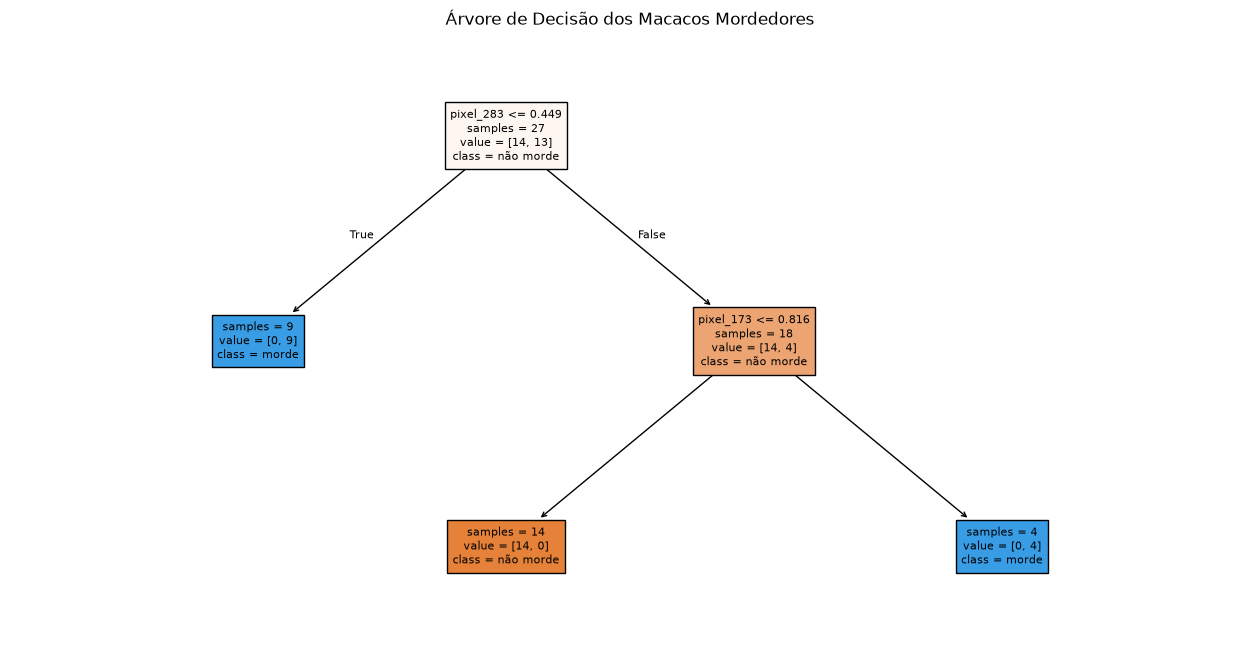

In [17]:
plt.figure(figsize=(16, 8))
plot_tree(
    modelo,
    filled=True,
    class_names=["não morde", "morde"],
    feature_names=[f"pixel_{i}" for i in range(X_treino.shape[1])],
    fontsize=8,
    impurity=False,
)
plt.title("Árvore de Decisão dos Macacos Mordedores")
plt.show()


## 6. Hora do teste! 🧪

Vamos ver se o computador acerta os macacos que ele **nunca viu** (o grupo de teste).


In [18]:
previsoes = modelo.predict(X_teste)

acertos = 0
for numero, real, previsto in zip(numeros_teste, y_teste, previsoes):
    certo_ou_errado = "✅ acertou" if real == previsto else "❌ errou"
    real_txt = "morde" if real == 1 else "não morde"
    previsto_txt = "morde" if previsto == 1 else "não morde"
    print(f"Macaco {numero:2d}: era '{real_txt}' | computador disse '{previsto_txt}'  -> {certo_ou_errado}")
    if real == previsto:
        acertos += 1

acuracia = accuracy_score(y_teste, previsoes)
print(f"\nO computador acertou {acertos} de {len(y_teste)} macacos.")
print(f"Acurácia: {acuracia*100:.0f}%")


Macaco  6: era 'morde' | computador disse 'não morde'  -> ❌ errou
Macaco 13: era 'morde' | computador disse 'morde'  -> ✅ acertou
Macaco 18: era 'morde' | computador disse 'não morde'  -> ❌ errou
Macaco 34: era 'morde' | computador disse 'morde'  -> ✅ acertou
Macaco  3: era 'não morde' | computador disse 'morde'  -> ❌ errou
Macaco  8: era 'não morde' | computador disse 'não morde'  -> ✅ acertou
Macaco 11: era 'não morde' | computador disse 'não morde'  -> ✅ acertou
Macaco 20: era 'não morde' | computador disse 'não morde'  -> ✅ acertou
Macaco 21: era 'não morde' | computador disse 'não morde'  -> ✅ acertou
Macaco 26: era 'não morde' | computador disse 'não morde'  -> ✅ acertou
Macaco 27: era 'não morde' | computador disse 'não morde'  -> ✅ acertou
Macaco 29: era 'não morde' | computador disse 'morde'  -> ❌ errou
Macaco 31: era 'não morde' | computador disse 'não morde'  -> ✅ acertou

O computador acertou 9 de 13 macacos.
Acurácia: 69%


## 7. Vamos conversar sobre o resultado 🤔

* O computador acertou tudo? Ou errou alguns?
* Ele estava realmente entendendo o que significa "morder", ou só encontrando padrões nos pixels
  (tipo óculos, tapa-olho, band-aid, língua de fora...) que **por acaso** apareciam nas imagens de treino?
* Isso é parecido com o que acontece com inteligências artificiais reais: elas aprendem os padrões que
  **estão nos dados que a gente mostra pra elas** — e não necessariamente a "verdade" sobre o mundo.
  Se os dados de treino tiverem um viés (bias), a IA aprende esse viés também!

### Desafio extra 🚀
Tente mudar o `max_depth` lá em cima (por exemplo, para 2 ou para 8) e rode tudo de novo.
A árvore fica mais simples ou mais complicada? A acurácia melhora ou piora?
